# Importing Data

In [83]:
import torch
from torchvision import datasets, transforms
from datasets import load_dataset

def importTestVariant(path):
    return datasets.ImageFolder(root=path, transform=test_variant_transforms)

# Main dataset
food = load_dataset("ethz/food101")

# Training set
train = food['train']
test = food['validation'] # DO NOT USE (use test_clean instead)

test_variant_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

clean_path = './test_splits/clean'
blur_little_path = './test_splits/blur_little'
blur_medium_path = './test_splits/blur_medium'
downsampled_path = './test_splits/downsampled'
masked_path = './test_splits/masked'
noise_rotation_path = './test_splits/noise_rotation'

# Test set variants
test_clean = importTestVariant(clean_path)
test_blur_little = importTestVariant(blur_little_path)
test_blur_medium = importTestVariant(blur_medium_path)
test_downsampled = importTestVariant(downsampled_path)
test_masked = importTestVariant(masked_path)
test_noise_rotation = importTestVariant(noise_rotation_path)

# Exploration

In [84]:
print("DATASET SIZES")
print()
print(f"Training: {len(train)}")
print(f"Test (Clean): {len(test_clean)}")
print()
print(f"Test (Blur Little): {len(test_blur_little)}")
print(f"Test (Blur Medium): {len(test_blur_medium)}")
print(f"Test (Downsampled): {len(test_downsampled)}")
print(f"Test (Masked): {len(test_masked)}")
print(f"Test (Noise Rotation): {len(test_noise_rotation)}")

DATASET SIZES

Training: 75750
Test (Clean): 25250

Test (Blur Little): 25250
Test (Blur Medium): 25250
Test (Downsampled): 25250
Test (Masked): 25250
Test (Noise Rotation): 25250


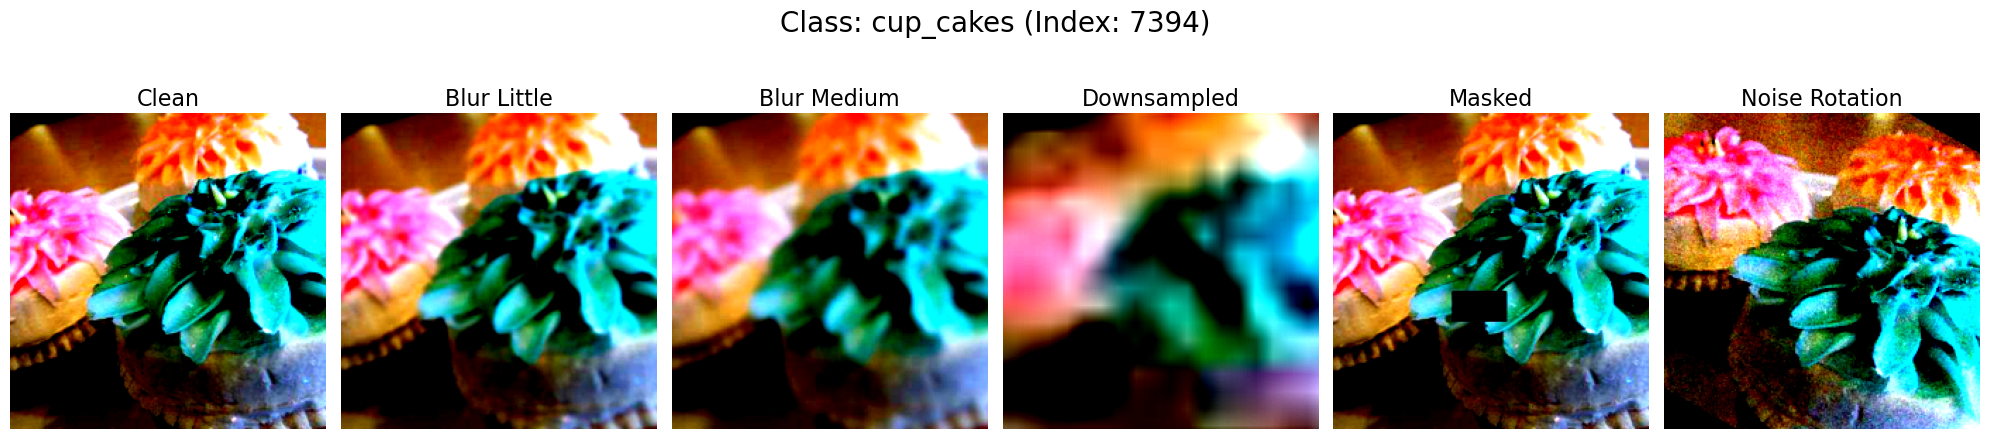

In [87]:
import matplotlib.pyplot as plt
import numpy as np
import random

test_sets = {
    "Clean": test_clean,
    "Blur Little": test_blur_little,
    "Blur Medium": test_blur_medium,
    "Downsampled": test_downsampled,
    "Masked": test_masked,
    "Noise Rotation": test_noise_rotation
}

random_idx = random.randint(0, len(test_sets["Clean"]) - 1)
_, label_idx = test_sets["Clean"][random_idx]
class_name = test_sets["Clean"].classes[label_idx]

fig, axes = plt.subplots(1, len(test_sets), figsize=(20, 5))

for i, (name, test_set) in enumerate(test_sets.items()):
    img_tensor, _ = test_set[random_idx]
    img = img_tensor.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1) 
    axes[i].imshow(img)
    axes[i].set_title(name, fontsize=16)
    axes[i].axis('off')

fig.suptitle(f"Class: {class_name} (Index: {random_idx})", fontsize=20)
plt.tight_layout()
plt.show()

In [86]:
food_classes = test_clean.classes

print(f"Number of Classes: {len(food_classes)}")
print()
print(', '.join(food_classes))

Number of Classes: 101

apple_pie, baby_back_ribs, baklava, beef_carpaccio, beef_tartare, beet_salad, beignets, bibimbap, bread_pudding, breakfast_burrito, bruschetta, caesar_salad, cannoli, caprese_salad, carrot_cake, ceviche, cheese_plate, cheesecake, chicken_curry, chicken_quesadilla, chicken_wings, chocolate_cake, chocolate_mousse, churros, clam_chowder, club_sandwich, crab_cakes, creme_brulee, croque_madame, cup_cakes, deviled_eggs, donuts, dumplings, edamame, eggs_benedict, escargots, falafel, filet_mignon, fish_and_chips, foie_gras, french_fries, french_onion_soup, french_toast, fried_calamari, fried_rice, frozen_yogurt, garlic_bread, gnocchi, greek_salad, grilled_cheese_sandwich, grilled_salmon, guacamole, gyoza, hamburger, hot_and_sour_soup, hot_dog, huevos_rancheros, hummus, ice_cream, lasagna, lobster_bisque, lobster_roll_sandwich, macaroni_and_cheese, macarons, miso_soup, mussels, nachos, omelette, onion_rings, oysters, pad_thai, paella, pancakes, panna_cotta, peking_duck, 

# Backbone

In [5]:
import torch.nn as nn
from torchvision import models

# Number of classes of food in the dataset
num_classes = 101

# ResNet18
resnet = models.resnet18(weights='IMAGENET1K_V1')
# Adjust the output layer for the specific number of classes
num_ftrs_res = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs_res, num_classes)

# EfficientNetV2-S
effnet = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
# Adjust the output layer for the specific number of classes
num_ftrs_eff = effnet.classifier[1].in_features
effnet.classifier[1] = nn.Linear(num_ftrs_eff, num_classes)

# Linear Probing (Baseline)

In [6]:
import copy

def freezeAllLayers(model):
    for param in model.parameters():
        param.requires_grad = False

# ResNet18 Baseline
resnet_baseline = copy.deepcopy(resnet)
freezeAllLayers(resnet_baseline)
# Unfreeze last layer
resnet_baseline.fc.weight.requires_grad = True
resnet_baseline.fc.bias.requires_grad = True

# EfficientNetV2-S Baseline
effnet_baseline = copy.deepcopy(effnet)
freezeAllLayers(effnet_baseline)
# Unfreeze last layer
effnet_baseline.classifier[1].weight.requires_grad = True
effnet_baseline.classifier[1].bias.requires_grad = True

# Model Evaluation

In [90]:
# Add any models you create
models_to_evaluate = {
    "resnet_baseline": resnet_baseline,
    "effnet_baseline": effnet_baseline
}

In [ ]:
import pandas as pd
from torch.utils.data import Subset

def evaluate(model, dataset):
    """
    Evaluates the accuracy of a model on a dataset. This function iterates 
    through the dataset in batches, performs a forward pass, and calculates the 
    percentage of correctly classified images.

    Args:
        model (torch.nn.Module): Model to evaluate. 
        dataset (torch.utils.data.Dataset): Dataset of images and labels.

    Returns:
        float: Accuracy between 0 and 1.
    """

    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct/total

model_accuracies = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Determine accuracy for each model
for model_name, model in models_to_evaluate.items():
    
    model.to(device)
    model.eval()
    
    for set_name, test_set in test_sets.items():
        
        accuracy = evaluate(model, test_set)
                
        model_accuracies.append({
            "Model": model_name,
            "Dataset": set_name,
            "Accuracy": accuracy
        })

        print(f"Processed {model_name} on the {set_name} test set, accuracy is {round(accuracy, 4)}")

In [89]:
model_evaluations = pd.DataFrame(model_accuracies)

# Collect accuracies of each model with the clean test set
clean_accuracies = {}
for model in model_evaluations.Model.unique():
    clean_accuracy = model_evaluations.query("Model == @model & Dataset == 'Clean'").Accuracy.item()
    clean_accuracies.update({model: clean_accuracy})

# Calculate robustness
model_evaluations["Robustness"] = model_evaluations.apply(
    lambda row: row["Accuracy"] / clean_accuracies.get(row["Model"], 1), axis=1
)

model_evaluations

,Model,Dataset,Accuracy,Robustness
0,resnet_baseline,Clean,0.011168,1.000000
1,resnet_baseline,Blur Little,0.010693,0.957447
2,resnet_baseline,Blur Medium,0.010337,0.925532
3,resnet_baseline,Downsampled,0.010851,0.971631
4,resnet_baseline,Masked,0.009861,0.882979
5,resnet_baseline,Noise Rotation,0.010772,0.964539
6,effnet_baseline,Clean,0.009941,1.000000
7,effnet_baseline,Blur Little,0.007921,0.796813
8,effnet_baseline,Blur Medium,0.007644,0.768924
9,effnet_baseline,Downsampled,0.008000,0.804781


In [82]:
# Filter out the Clean rows, variants only
model_evaluations_variants = model_evaluations.query("Dataset != 'Clean'")

# Calculate mean variant Accuracy and Robustness for each Model
variant_sumamary = model_evaluations_variants.groupby("Model")[["Accuracy", "Robustness"]].mean().reset_index()

# Rename columns to be more accurate
variant_sumamary.columns = ["Model", "Avg_Variant_Accuracy", "Avg_Variant_Robustness"]

variant_sumamary

,Model,Avg_Variant_Accuracy,Avg_Variant_Robustness
0,effnet_baseline,0.008935,0.898805
1,resnet_baseline,0.010503,0.940426
